In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# KALIAN BERDUA PAKAI FILE INI
df = pd.read_csv(r'D:\finish\New folder\Kuliah\Semester 6\Yapay Zeka\yapayzeka\Data\Processed\ecommerce_clean.csv')

# Langkah WAJIB: Ubah teks jadi angka agar model kalian berdua bisa jalan
le = LabelEncoder()
df['category_n'] = le.fit_transform(df['category'])
df['sub_cat_n'] = le.fit_transform(df['sub_category'])
df['region_n'] = le.fit_transform(df['region']) # Temanmu butuh ini sebagai target

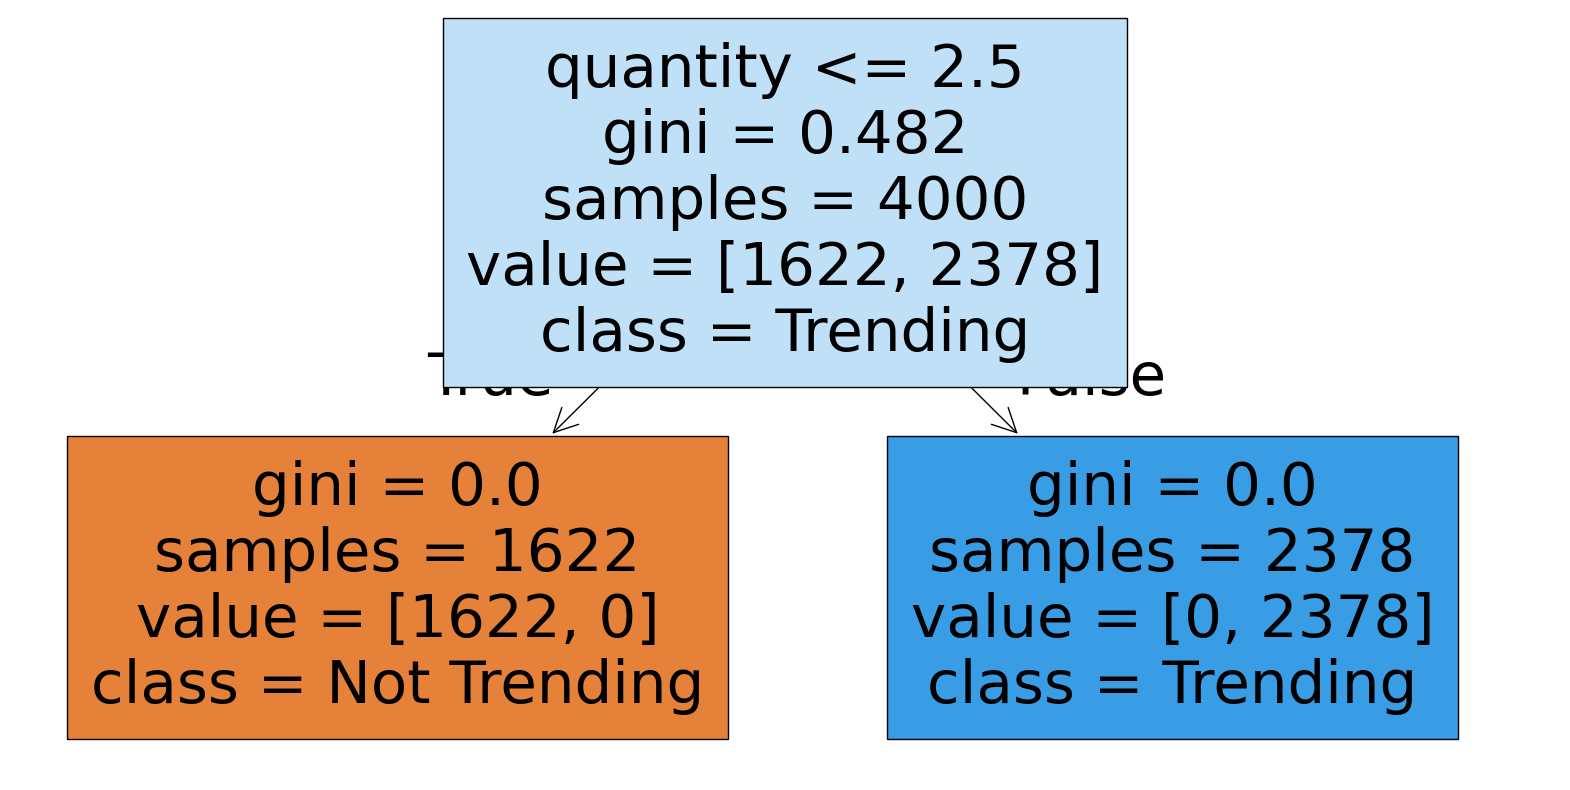

Akurasi Model Kamu: 100.00%


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# --- STEP 1: Pilih Fitur (X) dan Target (y) ---
# Fitur: Semua angka yang berpengaruh
X = df[['category_n', 'sub_cat_n', 'quantity', 'unit_price', 'discount', 'sales', 'profit']]
# Target: is_trending (Pastikan kolom ini sudah ada di file clean kamu)
y = df['is_trending'] 

# --- STEP 2: Bagi Data (80% Train, 20% Test) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 3: Training Model ---
model_bilal = DecisionTreeClassifier(max_depth=3) # max_depth 3 supaya pohonnya mudah dibaca
model_bilal.fit(X_train, y_train)

# --- STEP 4: Visualisasi Pohon (Penting untuk Laporan!) ---
plt.figure(figsize=(20,10))
tree.plot_tree(model_bilal, feature_names=X.columns, class_names=['Not Trending', 'Trending'], filled=True)
plt.show()

print(f"Akurasi Model Kamu: {model_bilal.score(X_test, y_test)*100:.2f}%")

In [22]:
import joblib

# 1. Simpan Modelnya
joblib.dump(model_bilal, 'model_trending.pkl')

# 2. Simpan LabelEncoder-nya (PENTING!) 
# Agar UI tahu 'Electronics' itu angka berapa
joblib.dump(le, 'label_encoder.pkl')

print("Model dan Encoder berhasil disimpan! Siap dipakai di UI.")

Model dan Encoder berhasil disimpan! Siap dipakai di UI.
